Using device: cuda
Label Mapping:
  0 -> Anxiety
  1 -> Depression
  2 -> Normal
  3 -> Suicidal

Loading model and running inference on test set...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: ./hf_models\roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Test Inference: 100%|██████████████████████████████████████████████████████████████| 233/233 [00:21<00:00, 10.68it/s]



Binary outcome definition: true label == 'Suicidal' (id=3)
Positive samples (Suicidal): 1682 / 7442

Brier Score: 0.117546
ECE Score:   0.152034

Calibration Bin Statistics (Uniform bins, n=10)
 Bin  Lower  Upper  Count  Mean Predicted  Observed Frequency  Absolute Gap
   1    0.0    0.1   2690          0.0174              0.0078        0.0096
   2    0.1    0.2    743          0.1588              0.0054        0.1534
   3    0.2    0.3    126          0.2447              0.0476        0.1970
   4    0.3    0.4    158          0.3511              0.0253        0.3257
   5    0.4    0.5    707          0.4734              0.0311        0.4422
   6    0.5    0.6    910          0.5333              0.1571        0.3762
   7    0.6    0.7    370          0.6485              0.3568        0.2918
   8    0.7    0.8    457          0.7546              0.5689        0.1856
   9    0.8    0.9    884          0.8475              0.7919        0.0556
  10    0.9    1.0    397          0.9360    

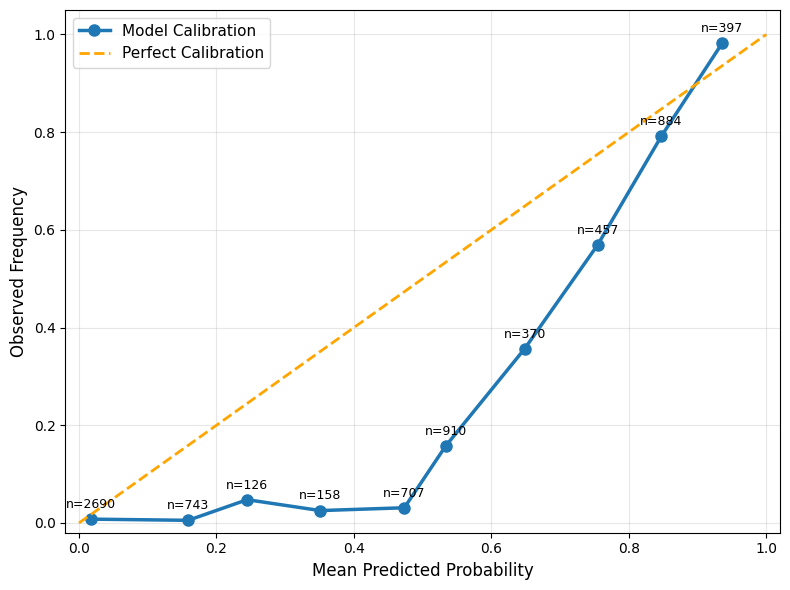

Saved: calibration_curve_with_bin_counts.png

Calibration bin experiment completed.


In [2]:
# ============================================================
# Calibration Bin Statistics
# ============================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import os
import random
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

LOCAL_MODEL_DIR = "./hf_models"
MODEL_PATH = os.path.join(LOCAL_MODEL_DIR, "roberta-base")
CHECKPOINT_PATH = "best_dual_regression.pt" 

df = pd.read_csv("mental_heath_unbanlanced.csv")
df = df.dropna(subset=["text", "status"])
df["text"] = df["text"].astype(str)

label_encoder = LabelEncoder()
df["label_encoded"] = label_encoder.fit_transform(df["status"])

print("Label Mapping:")
for i, name in enumerate(label_encoder.classes_):
    print(f"  {i} -> {name}")

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["text"].tolist(),
    df["label_encoded"].tolist(),
    test_size=0.3,
    random_state=42,
    stratify=df["label_encoded"]
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)


class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=96):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

class DualRegressionModel(nn.Module):
    def __init__(self, model_path):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_path, local_files_only=True)
        hidden = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(0.1)
        self.dep_head = nn.Linear(hidden, 1)
        self.sui_head = nn.Linear(hidden, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.dropout(outputs.last_hidden_state[:, 0, :])
        dep_score = torch.sigmoid(self.dep_head(cls)).squeeze(-1)
        sui_score = torch.sigmoid(self.sui_head(cls)).squeeze(-1)
        return {"dep_score": dep_score, "sui_score": sui_score}

# ====================== ECE ======================
def compute_ece(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    binids = np.digitize(y_prob, bins) - 1
    binids = np.clip(binids, 0, n_bins - 1)
    ece = 0.0
    for i in range(n_bins):
        mask = binids == i
        if np.sum(mask) > 0:
            bin_acc = np.mean(y_true[mask])
            bin_conf = np.mean(y_prob[mask])
            ece += (np.sum(mask) / len(y_true)) * abs(bin_acc - bin_conf)
    return ece

print("\nLoading model and running inference on test set...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, local_files_only=True)
test_dataset = TextDataset(test_texts, test_labels, tokenizer)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model = DualRegressionModel(MODEL_PATH).to(DEVICE)
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
model.eval()

all_sui_scores = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test Inference"):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].numpy()
        out = model(input_ids, attention_mask)
        all_sui_scores.extend(out["sui_score"].cpu().numpy())
        all_labels.extend(labels)

all_sui_scores = np.array(all_sui_scores)
all_labels = np.array(all_labels)


sui_class_id = list(label_encoder.classes_).index("Suicidal")
all_true_binary = (all_labels == sui_class_id).astype(int)

print(f"\nBinary outcome definition: true label == '{label_encoder.classes_[sui_class_id]}' (id={sui_class_id})")
print(f"Positive samples (Suicidal): {all_true_binary.sum()} / {len(all_true_binary)}")

# ====================== Brier & ECE ======================
brier = brier_score_loss(all_true_binary, all_sui_scores)
ece = compute_ece(all_true_binary, all_sui_scores, n_bins=10)

print(f"\nBrier Score: {brier:.6f}")
print(f"ECE Score:   {ece:.6f}")

N_BINS = 10
bin_edges = np.linspace(0.0, 1.0, N_BINS + 1)

bin_table = []

for i in range(N_BINS):
    if i == N_BINS - 1:
        mask = (all_sui_scores >= bin_edges[i]) & (all_sui_scores <= bin_edges[i+1])
    else:
        mask = (all_sui_scores >= bin_edges[i]) & (all_sui_scores < bin_edges[i+1])

    n = int(np.sum(mask))
    if n > 0:
        mean_pred = float(np.mean(all_sui_scores[mask]))
        obs_freq = float(np.mean(all_true_binary[mask]))
        abs_gap = abs(mean_pred - obs_freq)
    else:
        mean_pred = np.nan
        obs_freq = np.nan
        abs_gap = np.nan

    bin_table.append({
        "Bin": i + 1,
        "Lower": round(bin_edges[i], 2),
        "Upper": round(bin_edges[i+1], 2),
        "Count": n,
        "Mean Predicted": round(mean_pred, 4) if n > 0 else None,
        "Observed Frequency": round(obs_freq, 4) if n > 0 else None,
        "Absolute Gap": round(abs_gap, 4) if n > 0 else None
    })

bin_df = pd.DataFrame(bin_table)

print("\n" + "="*80)
print("Calibration Bin Statistics (Uniform bins, n=10)")
print("="*80)
print(bin_df.to_string(index=False))
print("="*80)


bin_df.to_csv("calibration_bin_statistics.csv", index=False)
print("\nSaved: calibration_bin_statistics.csv")

with open("calibration_bin_statistics.txt", "w", encoding="utf-8") as f:
    f.write("Calibration Bin Statistics\n")
    f.write("Binary outcome: 1 if true label == Suicidal, else 0\n")
    f.write(f"Brier Score: {brier:.6f}\n")
    f.write(f"ECE: {ece:.6f}\n\n")
    f.write(bin_df.to_string(index=False))
    f.write("\n\nNote: No post-hoc recalibration (Platt/isotonic) was applied.\n")
    f.write("Scores are raw sigmoid outputs trained with MSE against fixed class-derived targets.\n")

print("Saved: calibration_bin_statistics.txt")

prob_true, prob_pred = calibration_curve(
    all_true_binary, all_sui_scores, n_bins=10, strategy="uniform"
)

valid_counts = []
for i in range(N_BINS):
    if i == N_BINS - 1:
        mask = (all_sui_scores >= bin_edges[i]) & (all_sui_scores <= bin_edges[i+1])
    else:
        mask = (all_sui_scores >= bin_edges[i]) & (all_sui_scores < bin_edges[i+1])
    cnt = int(np.sum(mask))
    if cnt > 0:
        valid_counts.append(cnt)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker="o", linewidth=2.5, markersize=8, label="Model Calibration")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=2, color="orange", label="Perfect Calibration")

for x, y, n in zip(prob_pred, prob_true, valid_counts):
    plt.annotate(f"n={n}", xy=(x, y), xytext=(0, 8),
                 textcoords="offset points", ha="center", fontsize=9)

plt.xlabel("Mean Predicted Probability", fontsize=12)
plt.ylabel("Observed Frequency", fontsize=12)
plt.xlim(-0.02, 1.02)
plt.ylim(-0.02, 1.05)
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left", fontsize=11)
plt.tight_layout()
plt.savefig("calibration_curve_with_bin_counts.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: calibration_curve_with_bin_counts.png")

print("\nCalibration bin experiment completed.")